In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [4]:
con = duckdb.connect("../data/capstone.duckdb")

df = con.execute("""SELECT * FROM gold.mrt_customer_features WHERE Individual = 'Y'""").fetchdf()

print(df.columns)
print(df.shape)

Index(['customer_id', 'Individual', 'total_spend', 'transaction_count',
       'avg_transaction_amount', 'median_transaction_amount',
       'std_transaction_amount', 'max_transaction_amount',
       'min_transaction_amount', 'grocery_share', 'dining_share', 'gas_share',
       'digital_share', 'electronics_share', 'telecom_share', 'retail_share',
       'healthcare_share', 'pets_share', 'home_share', 'automotive_share',
       'clothing_share', 'entertainment_share', 'financial_share',
       'personal_care_share', 'transport_share', 'utilities_share',
       'government_share', 'other_share', 'weekend_share',
       'avg_transactions_per_week', 'dec_to_nov_daily_spend_ratio',
       'jan_to_dec_daily_spend_ratio', 'unique_merchants',
       'top_merchant_share', 'repeat_merchant_rate', 'repeat_transaction_rate',
       'avg_visits_per_merchant', 'Age', 'RelationshipYears', 'is_male',
       'is_female', 'NumberActiveDDAs', 'NumberActiveTimeDeposits',
       'NumberActiveLoans', 'Numb

In [64]:
identifier_cols = ['customer_id','Individual']

product_cols = ['has_deposit', 'has_loan', 'has_creditcard', 'has_atm', 'has_debit',
    'is_primary', 'is_wealth', 'is_payroll', 'is_pling', 'is_able',
    'NumberActiveDDAs', 'NumberActiveTimeDeposits', 
    'NumberActiveLoans', 'NumberCreditCardAccts']

feature_cols = [col for col in df.columns
                if col not in identifier_cols + product_cols]

print(f"Identifiers:        {len(identifier_cols)}")
print(f"Product holdings:   {len(product_cols)}")
print(f"Clustering features: {len(feature_cols)}")

Identifiers:        2
Product holdings:   14
Clustering features: 41


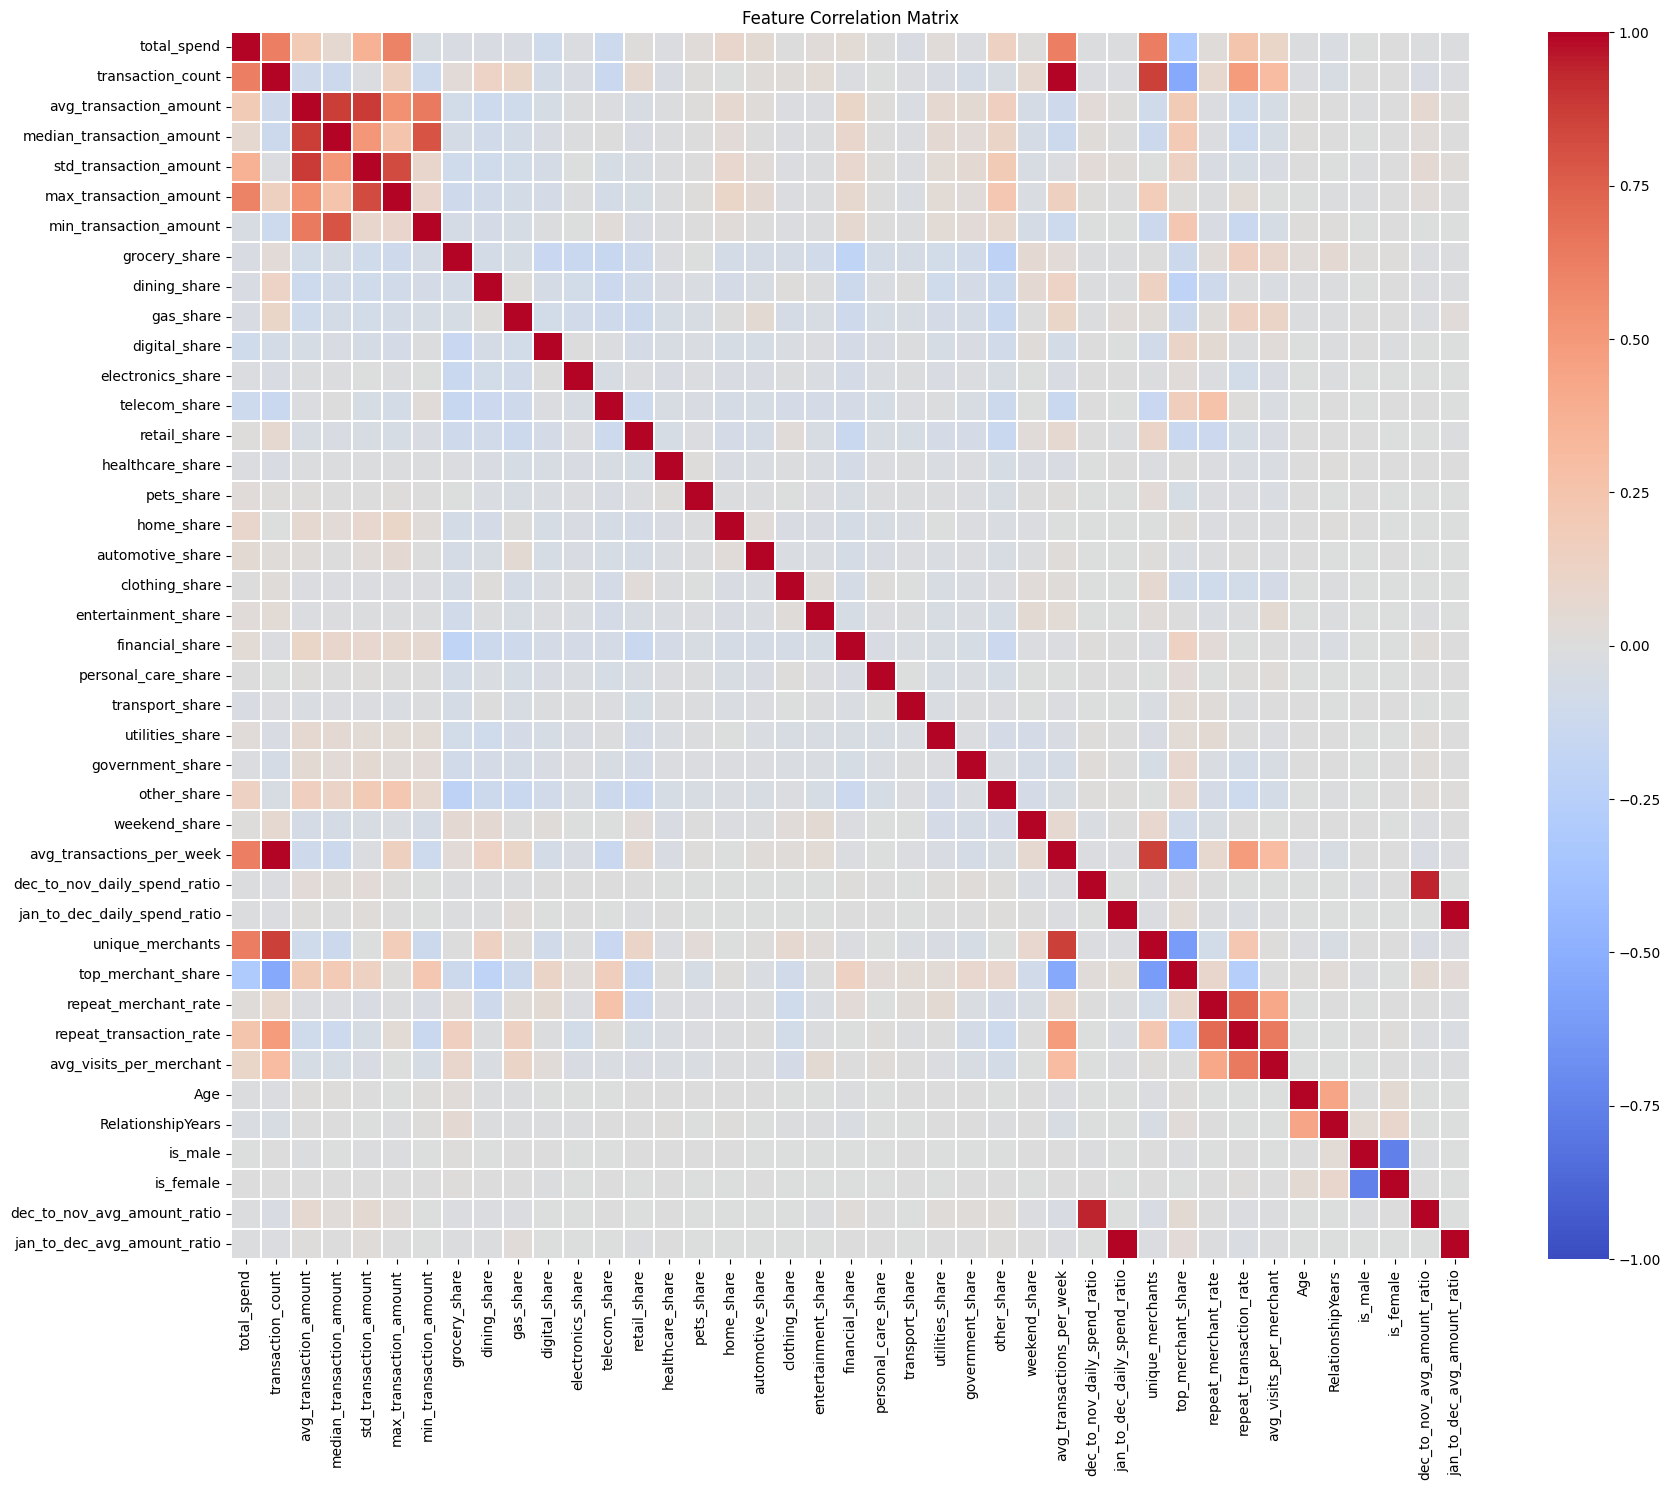

In [65]:
X = df[feature_cols].copy()

corr_matrix = X.corr()

# Heatmap
fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    annot=False,
    ax=ax
)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../figs/feature_selection/correlation_heatmap_full.png', dpi=150, bbox_inches='tight')
plt.show()


In [66]:
# find all pairs above the threshold
threshold = 0.85

corr_pairs = []
cols = corr_matrix.columns.tolist()

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        val = abs(corr_matrix.iloc[i, j])
        if val >= threshold:
            corr_pairs.append({
                'feature_a': cols[i],
                'feature_b': cols[j],
                'correlation': round(corr_matrix.iloc[i, j], 3)
            })

pairs_df = pd.DataFrame(corr_pairs).sort_values('correlation', ascending=False)
print(f"Pairs above {threshold} threshold: {len(pairs_df)}\n")
print(pairs_df.to_string(index=False))

Pairs above 0.85 threshold: 7

                   feature_a                   feature_b  correlation
           transaction_count   avg_transactions_per_week        1.000
jan_to_dec_daily_spend_ratio jan_to_dec_avg_amount_ratio        0.996
dec_to_nov_daily_spend_ratio dec_to_nov_avg_amount_ratio        0.938
      avg_transaction_amount      std_transaction_amount        0.881
      avg_transaction_amount   median_transaction_amount        0.873
           transaction_count            unique_merchants        0.863
   avg_transactions_per_week            unique_merchants        0.863


In [67]:
# features to drop based on correlation analysis
drop_correlated = [
    'transaction_count',            
    'jan_to_dec_avg_amount_ratio', 
    'dec_to_nov_avg_amount_ratio',  
    'avg_transaction_amount',       
    'std_transaction_amount',       
]

# apply drops
feature_cols_pruned = [col for col in feature_cols if col not in drop_correlated]

print(f"Before correlation pruning:  {len(feature_cols)} features")
print(f"Dropped:                     {len(drop_correlated)} features")
print(f"After correlation pruning:   {len(feature_cols_pruned)} features")
print(f"\nDropped features:")
for col in drop_correlated:
    print(f"  {col}")

Before correlation pruning:  41 features
Dropped:                     5 features
After correlation pruning:   36 features

Dropped features:
  transaction_count
  jan_to_dec_avg_amount_ratio
  dec_to_nov_avg_amount_ratio
  avg_transaction_amount
  std_transaction_amount


In [68]:
# compute variance for each remaining feature
X_pruned = df[feature_cols_pruned].copy()

variance = X_pruned.var().sort_values(ascending=True)

print("Bottom 10 features by variance:")
print(variance.head(10).round(6).to_string())

Bottom 10 features by variance:
pets_share              0.00228
transport_share        0.002553
clothing_share         0.002855
automotive_share       0.004743
healthcare_share       0.005958
personal_care_share    0.006522
home_share             0.006685
entertainment_share    0.007116
government_share       0.007576
utilities_share        0.009641


In [69]:
# organize remaining features by family for domain review
feature_families = {
    'Spending Aggregates': [
        'total_spend', 'avg_transactions_per_week',
        'median_transaction_amount', 'max_transaction_amount', 'min_transaction_amount'
    ],
    'Category Shares': [
        'grocery_share', 'dining_share', 'gas_share', 'digital_share',
        'electronics_share', 'telecom_share', 'retail_share', 'healthcare_share',
        'pets_share', 'home_share', 'automotive_share', 'clothing_share',
        'entertainment_share', 'financial_share', 'personal_care_share',
        'transport_share', 'utilities_share', 'government_share', 'other_share'
    ],
    'Temporal': [
        'weekend_share', 'dec_to_nov_daily_spend_ratio', 'jan_to_dec_daily_spend_ratio'
    ],
    'Merchant Behavior': [
        'unique_merchants', 'top_merchant_share',
        'repeat_merchant_rate', 'repeat_transaction_rate', 'avg_visits_per_merchant'
    ],
    'Demographics': [
        'Age', 'RelationshipYears', 'is_male', 'is_female'
    ]
}

print("36 features organized by family:\n")
total = 0
for family, cols in feature_families.items():
    # check all are actually in our pruned list
    in_set = [c for c in cols if c in feature_cols_pruned]
    total += len(in_set)
    print(f"{family} ({len(in_set)}):")
    for c in in_set:
        print(f"  {c}")
    print()

print(f"Total: {total}")

36 features organized by family:

Spending Aggregates (5):
  total_spend
  avg_transactions_per_week
  median_transaction_amount
  max_transaction_amount
  min_transaction_amount

Category Shares (19):
  grocery_share
  dining_share
  gas_share
  digital_share
  electronics_share
  telecom_share
  retail_share
  healthcare_share
  pets_share
  home_share
  automotive_share
  clothing_share
  entertainment_share
  financial_share
  personal_care_share
  transport_share
  utilities_share
  government_share
  other_share

Temporal (3):
  weekend_share
  dec_to_nov_daily_spend_ratio
  jan_to_dec_daily_spend_ratio

Merchant Behavior (5):
  unique_merchants
  top_merchant_share
  repeat_merchant_rate
  repeat_transaction_rate
  avg_visits_per_merchant

Demographics (4):
  Age
  RelationshipYears
  is_male
  is_female

Total: 36


In [70]:
# features to drop based on domain relevance
drop_domain = [
    'max_transaction_amount', 
    'min_transaction_amount',
    'repeat_transaction_rate',  
]

# apply drops
feature_cols_final = [col for col in feature_cols_pruned if col not in drop_domain]

print(f"After correlation pruning:   {len(feature_cols_pruned)} features")
print(f"Dropped:  {len(drop_domain)} features")
print(f"Final feature set:           {len(feature_cols_final)} features")
print(f"\nDropped features:")
for col in drop_domain:
    print(f"  {col}")
print(f"\nFinal feature set:")
for col in feature_cols_final:
    print(f"  {col}")

After correlation pruning:   36 features
Dropped:  3 features
Final feature set:           33 features

Dropped features:
  max_transaction_amount
  min_transaction_amount
  repeat_transaction_rate

Final feature set:
  total_spend
  median_transaction_amount
  grocery_share
  dining_share
  gas_share
  digital_share
  electronics_share
  telecom_share
  retail_share
  healthcare_share
  pets_share
  home_share
  automotive_share
  clothing_share
  entertainment_share
  financial_share
  personal_care_share
  transport_share
  utilities_share
  government_share
  other_share
  weekend_share
  avg_transactions_per_week
  dec_to_nov_daily_spend_ratio
  jan_to_dec_daily_spend_ratio
  unique_merchants
  top_merchant_share
  repeat_merchant_rate
  avg_visits_per_merchant
  Age
  RelationshipYears
  is_male
  is_female


In [71]:
# step 1 -- isolate final features
X = df[feature_cols_final].copy()

# step 2 -- check nulls then impute
print("Nulls before imputation:")
null_counts = X.isnull().sum()
print(null_counts[null_counts > 0])

# impute nulls
X['dec_to_nov_daily_spend_ratio'] = X['dec_to_nov_daily_spend_ratio'].fillna(1.0)
X['jan_to_dec_daily_spend_ratio'] = X['jan_to_dec_daily_spend_ratio'].fillna(1.0)
X['RelationshipYears'] = X['RelationshipYears'].fillna(X['RelationshipYears'].median())

# catch any remaining nulls with column median
for col in X.columns:
    if X[col].isnull().sum() > 0:
        X[col] = X[col].fillna(X[col].median())
        print(f"  filled remaining nulls in {col} with median")

print(f"\nNulls after imputation: {X.isnull().sum().sum()}")

# step 3 -- remove outliers aligned to X index
mask = ~((df.loc[X.index, 'transaction_count'] <= 10) & 
         (df.loc[X.index, 'avg_transaction_amount'] > 1000))
X = X[mask]
print(f"After outlier removal: {len(X):,} customers")

# step 4 -- log transform skewed columns
log_cols = [
    'total_spend', 'avg_transactions_per_week',
    'median_transaction_amount', 'unique_merchants',
    'avg_visits_per_merchant'
]
for col in log_cols:
    X[col] = np.log1p(X[col])

# step 5 -- cap ratio columns at p5/p95
ratio_cols = [
    'dec_to_nov_daily_spend_ratio',
    'jan_to_dec_daily_spend_ratio',
    'top_merchant_share',
    'repeat_merchant_rate'
]
for col in ratio_cols:
    p5  = X[col].quantile(0.05)
    p95 = X[col].quantile(0.95)
    X[col] = X[col].clip(p5, p95)

# step 6 -- scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Final shape for clustering: {X_scaled.shape}")

Nulls before imputation:
dec_to_nov_daily_spend_ratio    11196
jan_to_dec_daily_spend_ratio     7037
RelationshipYears                   9
dtype: int64

Nulls after imputation: 0
After outlier removal: 58,677 customers
Final shape for clustering: (58677, 33)


In [72]:
k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels,  sample_size=10000, random_state=42)
    silhouettes.append(sil)
    print(f"  k={k}  inertia={km.inertia_:>12,.0f}  silhouette={sil:.4f}")

  k=2  inertia=   1,773,489  silhouette=0.2056
  k=3  inertia=   1,706,112  silhouette=0.0340
  k=4  inertia=   1,655,723  silhouette=0.0411
  k=5  inertia=   1,619,441  silhouette=0.0426
  k=6  inertia=   1,569,450  silhouette=0.0533
  k=7  inertia=   1,529,162  silhouette=0.0595
  k=8  inertia=   1,493,160  silhouette=0.0650
  k=9  inertia=   1,451,446  silhouette=0.0651
  k=10  inertia=   1,407,190  silhouette=0.0826


In [73]:
# 41 features having no identifiers, no product holdings
X_41 = df[feature_cols].copy()  

# impute nulls
X_41['dec_to_nov_daily_spend_ratio'] = X_41['dec_to_nov_daily_spend_ratio'].fillna(1.0)
X_41['jan_to_dec_daily_spend_ratio'] = X_41['jan_to_dec_daily_spend_ratio'].fillna(1.0)
X_41['RelationshipYears'] = X_41['RelationshipYears'].fillna(X_41['RelationshipYears'].median())

for col in X_41.columns:
    if X_41[col].isnull().sum() > 0:
        X_41[col] = X_41[col].fillna(X_41[col].median())

# remove outliers
mask = ~((df['transaction_count'] <= 10) & (df['avg_transaction_amount'] > 1000))
X_41 = X_41[mask]

# log transform
log_cols = [
    'total_spend', 'avg_transactions_per_week',
    'median_transaction_amount', 'unique_merchants',
    'avg_visits_per_merchant'
]
for col in log_cols:
    if col in X_41.columns:
        X_41[col] = np.log1p(X_41[col])

# cap ratios
ratio_cols = [
    'dec_to_nov_daily_spend_ratio',
    'jan_to_dec_daily_spend_ratio',
    'top_merchant_share',
    'repeat_merchant_rate'
]
for col in ratio_cols:
    p5  = X_41[col].quantile(0.05)
    p95 = X_41[col].quantile(0.95)
    X_41[col] = X_41[col].clip(p5, p95)

# scale
scaler_41 = StandardScaler()
X_41_scaled = scaler_41.fit_transform(X_41)

print(f"Shape: {X_41_scaled.shape}")

# k-selection loop
print("\nK-Means results (41 features):\n")
inertias_41 = []
silhouettes_41 = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_41_scaled)
    inertia = km.inertia_
    sil = silhouette_score(X_41_scaled, labels, sample_size=10000, random_state=42)
    inertias_41.append(inertia)
    silhouettes_41.append(sil)
    print(f"  k={k}  inertia={inertia:>12,.0f}  silhouette={sil:.4f}")

Shape: (58677, 41)

K-Means results (41 features):

  k=2  inertia=   2,197,888  silhouette=0.1902
  k=3  inertia=   2,111,931  silhouette=0.1699
  k=4  inertia=   2,049,797  silhouette=0.0281
  k=5  inertia=   1,998,501  silhouette=0.0249
  k=6  inertia=   1,943,292  silhouette=0.0251
  k=7  inertia=   1,903,874  silhouette=0.0286
  k=8  inertia=   1,857,634  silhouette=0.0392
  k=9  inertia=   1,818,999  silhouette=0.0419
  k=10  inertia=   1,783,589  silhouette=0.0369


In [74]:
# build 57-feature scaled matrix for multi-metric evaluation
X_57 = df.copy()

# impute nulls
X_57['dec_to_nov_daily_spend_ratio'] = X_57['dec_to_nov_daily_spend_ratio'].fillna(1.0)
X_57['jan_to_dec_daily_spend_ratio'] = X_57['jan_to_dec_daily_spend_ratio'].fillna(1.0)
X_57['RelationshipYears'] = X_57['RelationshipYears'].fillna(X_57['RelationshipYears'].median())

for col in X_57.columns:
    if X_57[col].isnull().sum() > 0:
        X_57[col] = X_57[col].fillna(X_57[col].median())

# remove outliers
mask = ~((df['transaction_count'] <= 10) & (df['avg_transaction_amount'] > 1000))
X_57 = X_57[mask]

# drop non-numeric columns
X_57 = X_57.select_dtypes(include=[np.number])

# log transform
log_cols = [
    'total_spend', 'avg_transactions_per_week',
    'median_transaction_amount', 'unique_merchants',
    'avg_visits_per_merchant'
]
for col in log_cols:
    if col in X_57.columns:
        X_57[col] = np.log1p(X_57[col])

# cap ratios
ratio_cols = [
    'dec_to_nov_daily_spend_ratio',
    'jan_to_dec_daily_spend_ratio',
    'top_merchant_share',
    'repeat_merchant_rate'
]
for col in ratio_cols:
    if col in X_57.columns:
        p5  = X_57[col].quantile(0.05)
        p95 = X_57[col].quantile(0.95)
        X_57[col] = X_57[col].clip(p5, p95)

# scale
scaler_57 = StandardScaler()
X_57_scaled = scaler_57.fit_transform(X_57)

print(f"57-feature matrix shape: {X_57_scaled.shape}")

57-feature matrix shape: (58677, 55)


In [75]:
k_range = range(2, 11)
results = []

print("K-Means multi-metric evaluation (57 features):\n")
print(f"{'k':<5} {'Inertia':>12} {'Silhouette':>12} {'Davies-Bouldin':>16} {'Calinski-Harabasz':>19}")
print("-" * 70)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_57_scaled)
    
    inertia = km.inertia_
    sil     = silhouette_score(X_57_scaled, labels, sample_size=10000, random_state=42)
    db      = davies_bouldin_score(X_57_scaled, labels)
    ch      = calinski_harabasz_score(X_57_scaled, labels)
    
    results.append({
        'k': k,
        'inertia': inertia,
        'silhouette': sil,
        'davies_bouldin': db,
        'calinski_harabasz': ch
    })
    
    print(f"{k:<5} {inertia:>12,.0f} {sil:>12.4f} {db:>16.4f} {ch:>19.2f}")

results_df = pd.DataFrame(results)

K-Means multi-metric evaluation (57 features):

k          Inertia   Silhouette   Davies-Bouldin   Calinski-Harabasz
----------------------------------------------------------------------
2        3,019,336       0.1498           3.4088             4040.13
3        2,933,244       0.0634           3.2300             2940.36
4        2,850,226       0.0664           3.0918             2586.96
5        2,756,092       0.0762           2.6067             2507.44
6        2,692,910       0.0132           2.9537             2328.29
7        2,644,462       0.0332           3.0404             2154.90
8        2,588,854       0.0815           2.5476             2066.73
9        2,527,473       0.0748           2.2573             2030.37
10       2,480,895       0.0315           2.4911             1961.01
